In [2]:
import cftime
import pandas as pd
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from scipy.ndimage import label
from pathlib import Path

In [ ]:
daily_ds_hist = xr.open_zarr(
    "/data1/michsh/combined_thirstwave/HIST_tw_metrics.zarr"
)

daily_ds_ftr = xr.open_zarr(
    "/data1/michsh/combined_thirstwave/FTR_tw_metrics.zarr"
)

lat = daily_ds_ftr['lat'].values
lon = daily_ds_ftr['lon'].values
lon_adj = daily_ds_ftr['lon'].values - 180

print(lat)
print(lon)
print(lon_adj)

daily_ds_ftr

[24.03141361 24.97382199 25.91623037 26.85863874 27.80104712 28.7434555
 29.68586387 30.62827225 31.57068063 32.51308901 33.45549738 34.39790576
 35.34031414 36.28272251 37.22513089 38.16753927 39.10994764 40.05235602
 40.9947644  41.93717277 42.87958115 43.82198953 44.76439791 45.70680628
 46.64921466 47.59162304 48.53403141 49.47643979 50.41884817 51.36125654]
[235.   236.25 237.5  238.75 240.   241.25 242.5  243.75 245.   246.25
 247.5  248.75 250.   251.25 252.5  253.75 255.   256.25 257.5  258.75
 260.   261.25 262.5  263.75 265.   266.25 267.5  268.75 270.   271.25
 272.5  273.75 275.   276.25 277.5  278.75 280.   281.25 282.5  283.75
 285.   286.25 287.5  288.75 290.   291.25 292.5 ]
[ 55.    56.25  57.5   58.75  60.    61.25  62.5   63.75  65.    66.25
  67.5   68.75  70.    71.25  72.5   73.75  75.    76.25  77.5   78.75
  80.    81.25  82.5   83.75  85.    86.25  87.5   88.75  90.    91.25
  92.5   93.75  95.    96.25  97.5   98.75 100.   101.25 102.5  103.75
 105.   106.25 1

<xarray.Dataset> Size: 33GB
Dimensions:          (AMOC: 4, member: 20, time: 18404, lat: 30, lon: 47)
Coordinates:
  * AMOC             (AMOC) object 32B '1231' '1251' '1281' '1301'
    dayofyear        (time) float64 147kB dask.array<chunksize=(18404,), meta=np.ndarray>
  * lat              (lat) float64 240B 24.03 24.97 25.92 ... 49.48 50.42 51.36
  * lon              (lon) float64 376B 235.0 236.2 237.5 ... 290.0 291.2 292.5
  * member           (member) object 160B '001' '002' '003' ... '019' '020'
  * time             (time) object 147kB 2015-04-01 00:00:00 ... 2100-10-31 0...
Data variables:
    ET_os            (AMOC, member, time, lat, lon) float32 8GB dask.array<chunksize=(1, 1, 18404, 25, 25), meta=np.ndarray>
    actual_tw_ET_os  (AMOC, member, time, lat, lon) float32 8GB dask.array<chunksize=(1, 1, 18404, 25, 25), meta=np.ndarray>
    event_id         (AMOC, member, lat, lon, time) int32 8GB dask.array<chunksize=(1, 1, 25, 25, 18404), meta=np.ndarray>
    tw_intensity     (AMOC, member, time, lat, lon) float32 8GB dask.array<chunksize=(1, 1, 18404, 25, 25), meta=np.ndarray>

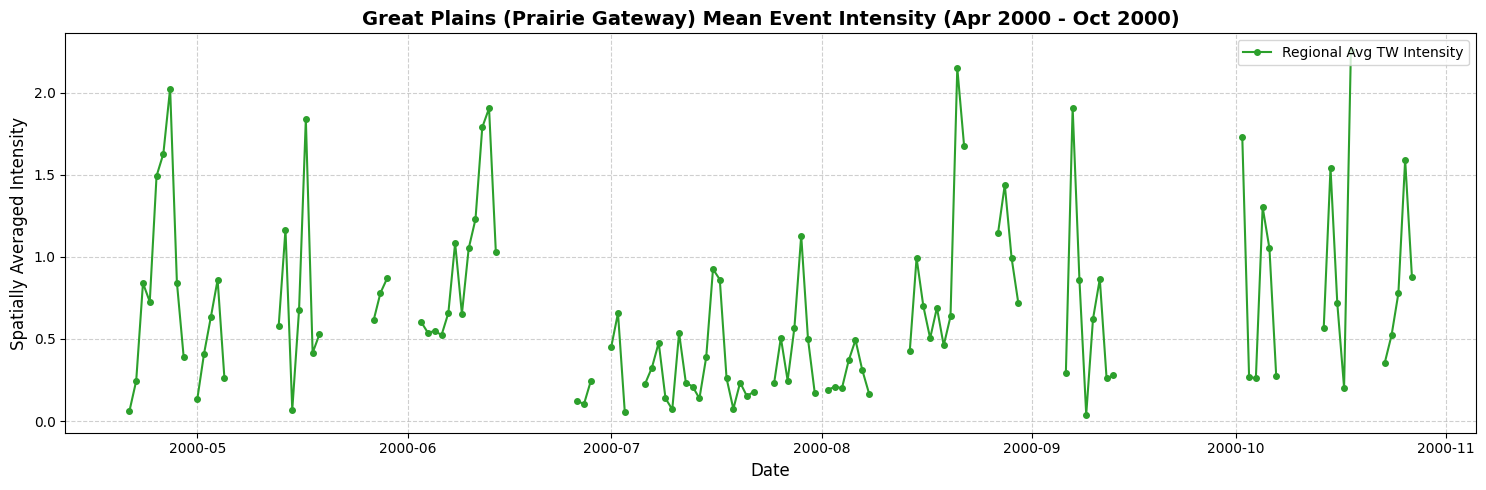

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Select the categorical dimensions
step1 = daily_ds_hist.tw_intensity.sel(AMOC="1231", member="001")

# 2. Slice for the Great Plains / Prairie Gateway region and spatially average
# Note: Since your lons are 235-292, 255 to 265 covers the Southern Great Plains.
# If your lats are stored from low to high, use slice(26, 42).
region_series = (
    step1.sel(
        lat=slice(26, 42),
        lon=slice(255, 265),
    )
    .mean(dim=["lat", "lon"], skipna=True)
    .sel(time=slice("2000-04-01", "2000-10-31"))
)

# 3. Convert cftime objects to standard pandas Timestamps
plot_dates = [
    pd.Timestamp(year=t.year, month=t.month, day=t.day)
    for t in region_series.time.values
]

# 4. Plot the regional timeline
plt.figure(figsize=(15, 5))

plt.plot(
    plot_dates,
    region_series.values,
    marker="o",
    markersize=4,
    linestyle="-",
    color="#2ca02c",  # Switched to green for the prairie region!
    label="Regional Avg TW Intensity",
)

plt.title(
    "Great Plains (Prairie Gateway) Mean Event Intensity (Apr 2000 - Oct 2000)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Spatially Averaged Intensity", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [5]:
# Calculated the FOE of tw_intencity. This metric only encompuses days that are tw's and then calculates the value of intencity. 

datasets = {
    "hist": daily_ds_hist,
    "ftr": daily_ds_ftr,
}

FOE_values = [0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 4]

FOE = {}

for period, ds in datasets.items():
    for threshold in FOE_values:
        FOE[(period, threshold)] = (
            (ds.tw_intensity >= threshold)
            .mean(("AMOC", "member", "time")) * 100
        )

print(FOE[('hist', 0.25)].values)

[[1.75169924 1.77977202 1.81973945 ... 0.82579298 0.80331351 0.77980742]
 [1.81439394 1.81839422 1.84852025 ... 0.88317757 0.84653781 0.7980034 ]
 [1.87475219 1.85641461 1.88278816 ... 0.92958794 0.87793826 0.83425375]
 ...
 [4.69013735 4.60467998 4.23491929 ... 1.78416171 1.79095865 1.61303455]
 [4.50573492 3.79219768 3.45468706 ... 1.77577174 1.72773294 1.6925092 ]
 [3.67696828 3.46229822 3.34257293 ... 1.79088785 1.79414472 1.67261399]]


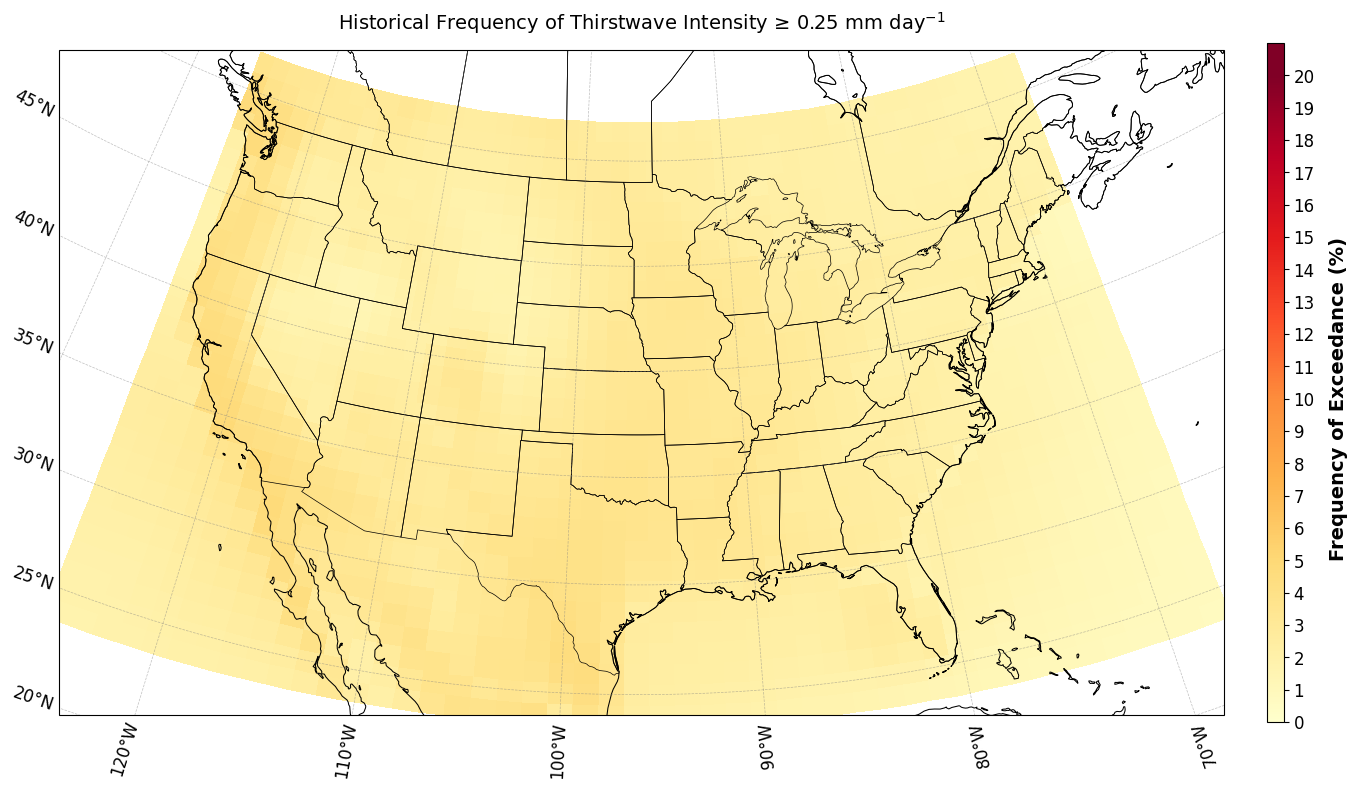

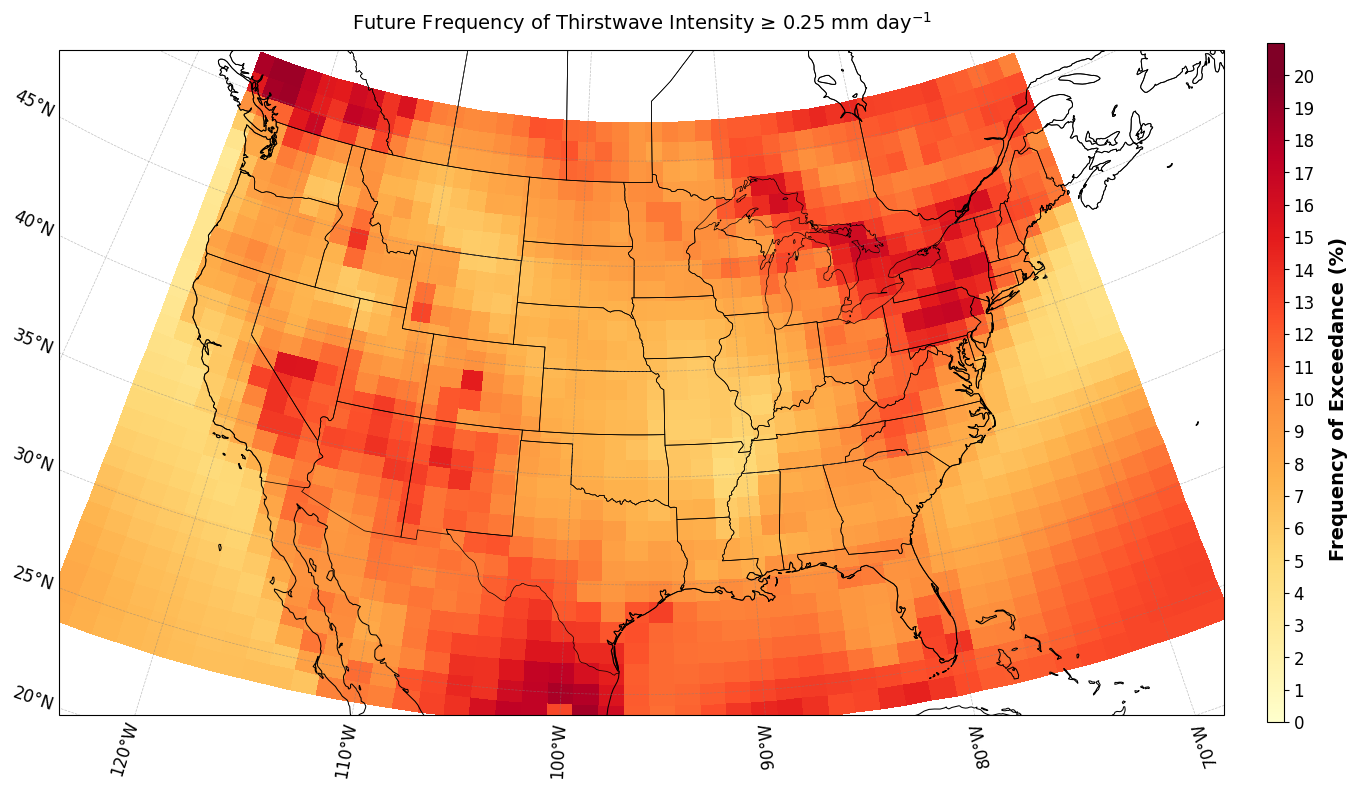

In [6]:
# Pair each DataArray with its specific title to avoid the array-comparison bug
plots_and_titles = [
    (FOE[('hist', 0.25)], 'Historical Frequency of Thirstwave Intensity ≥ 0.25 mm day$^{-1}$'),
    (FOE[('ftr', 0.25)], 'Future Frequency of Thirstwave Intensity ≥ 0.25 mm day$^{-1}$')
]

for plot, title in plots_and_titles:
    # Define the plot bounds 
    s_lat, n_lat = 24, 52
    w_lon, e_lon = -125, -67

    # Bounding box matching the Lambert Conformal format
    crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

    # Create the plot
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=crs)

    # Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    # Map features
    ax.coastlines('50m', linewidth=0.75)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.5)

    # Calculate ticks dynamically based on the max value
    data_max = float(plot.max())
    max_even = int(np.ceil(data_max / 2) * 2)
    
    # Safeguard step size so you don't end up with hundreds of ticks if max_even is large
    custom_ticks = list(range(0,21,1))

    # Render the background color fill
    im = plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='YlOrRd', 
                   add_colorbar=False, vmin=0.0, vmax=20, robust=True)

    # Drawing gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                      color='gray', alpha=0.5, linestyle='--')

    # Restrict labels to ONLY the bottom and left
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # Style the labels
    gl.xlabel_style = {'size': 12, 'color': 'black'}
    gl.ylabel_style = {'size': 12, 'color': 'black'}

    # Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

    # Vertical colorbar configuration (Now unified for both plots)
    cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                      aspect=40, extend='max', extendrect=True, ticks=custom_ticks) 

    # Colorbar label settings with nice subscripts
    cb.set_label('Frequency of Exceedance (%)', size=14, weight='bold', labelpad=10)
    cb.ax.tick_params(labelsize=12)

    # Dynamic Title
    plt.title(title, fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

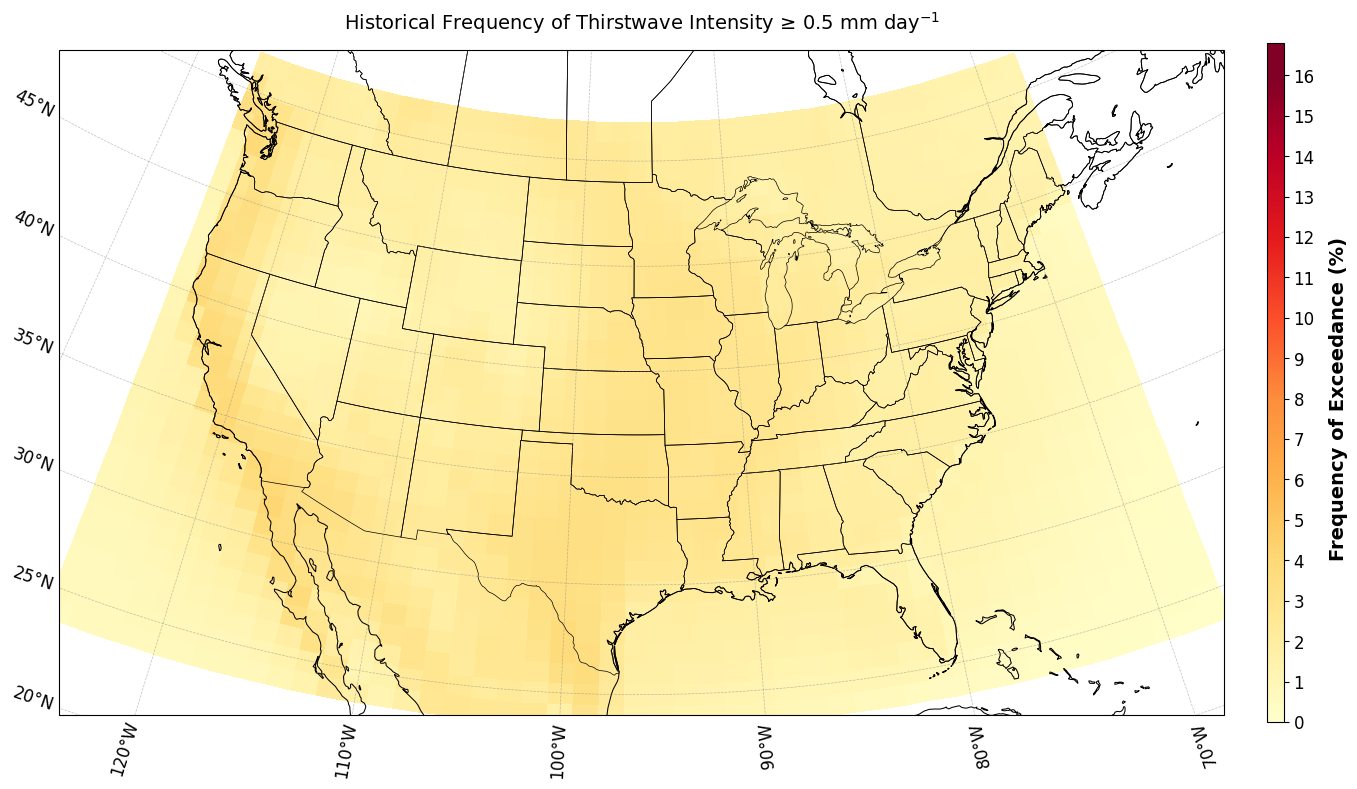

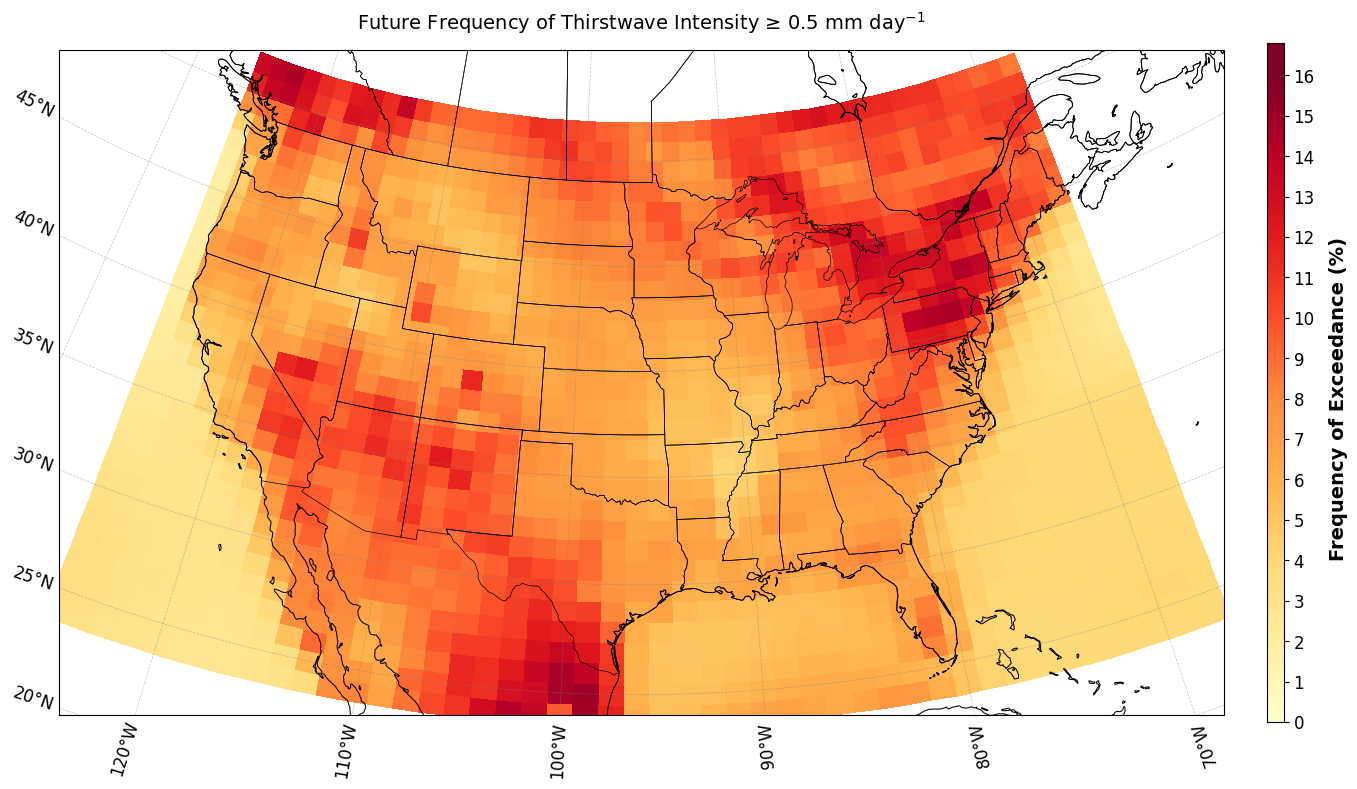

In [7]:
# Pair each DataArray with its specific title to avoid the array-comparison bug
plots_and_titles = [
    (FOE[('hist', .5)], 'Historical Frequency of Thirstwave Intensity ≥ 0.5 mm day$^{-1}$'),
    (FOE[('ftr', .5)], 'Future Frequency of Thirstwave Intensity ≥ 0.5 mm day$^{-1}$')
]

for plot, title in plots_and_titles:
    # Define the plot bounds 
    s_lat, n_lat = 24, 52
    w_lon, e_lon = -125, -67

    # Bounding box matching the Lambert Conformal format
    crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

    # Create the plot
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=crs)

    # Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    # Map features
    ax.coastlines('50m', linewidth=0.75)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.5)

    # Calculate ticks dynamically based on the max value
    data_max = float(plot.max())
    max_even = int(np.ceil(data_max / 2) * 2)
    
    # Safeguard step size so you don't end up with hundreds of ticks if max_even is large
    custom_ticks = list(range(0,21,1))

    # Render the background color fill
    im = plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='YlOrRd', 
                   add_colorbar=False, vmin=0.0, vmax=16, robust=True)

    # Drawing gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                      color='gray', alpha=0.5, linestyle='--')

    # Restrict labels to ONLY the bottom and left
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # Style the labels
    gl.xlabel_style = {'size': 12, 'color': 'black'}
    gl.ylabel_style = {'size': 12, 'color': 'black'}

    # Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

    # Vertical colorbar configuration (Now unified for both plots)
    cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                      aspect=40, extend='max', extendrect=True, ticks=custom_ticks) 

    # Colorbar label settings with nice subscripts
    cb.set_label('Frequency of Exceedance (%)', size=14, weight='bold', labelpad=10)
    cb.ax.tick_params(labelsize=12)

    # Dynamic Title
    plt.title(title, fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

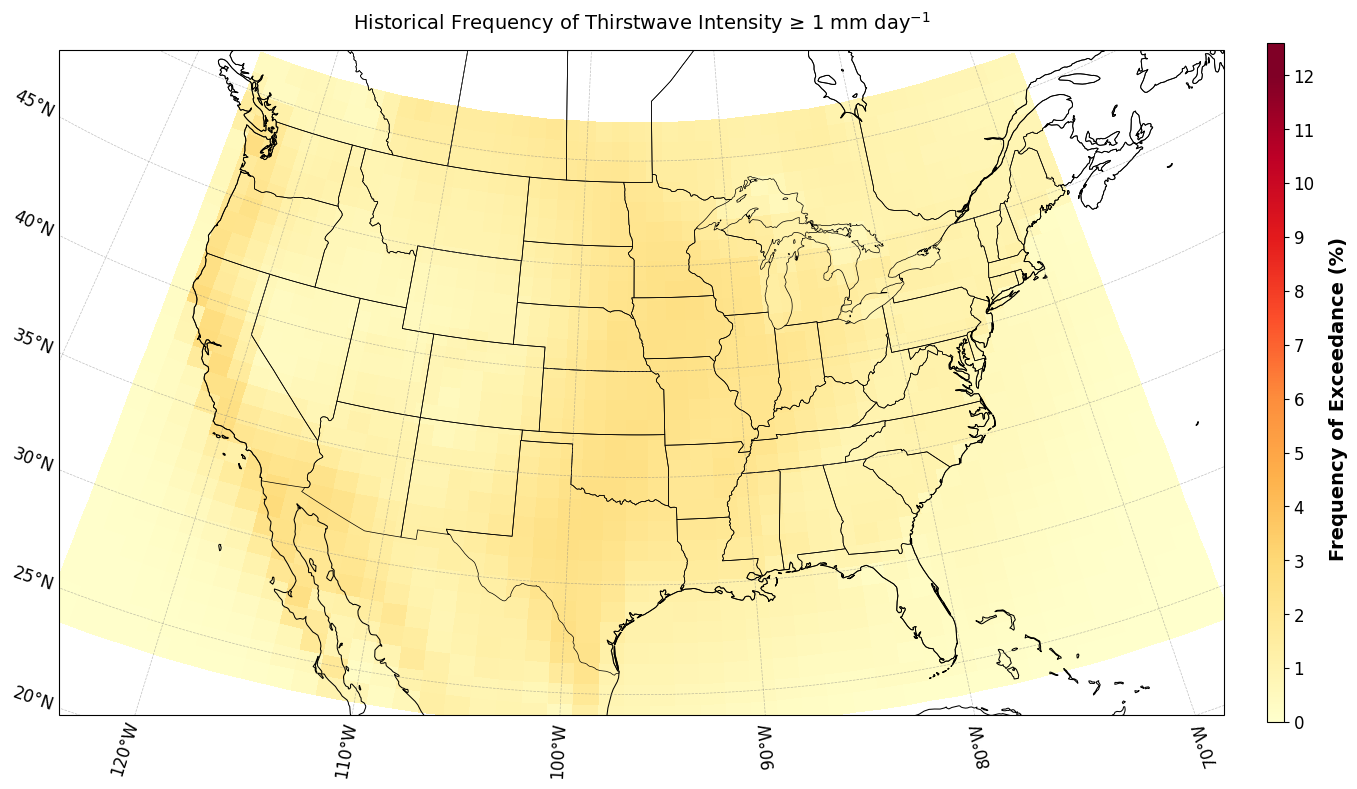

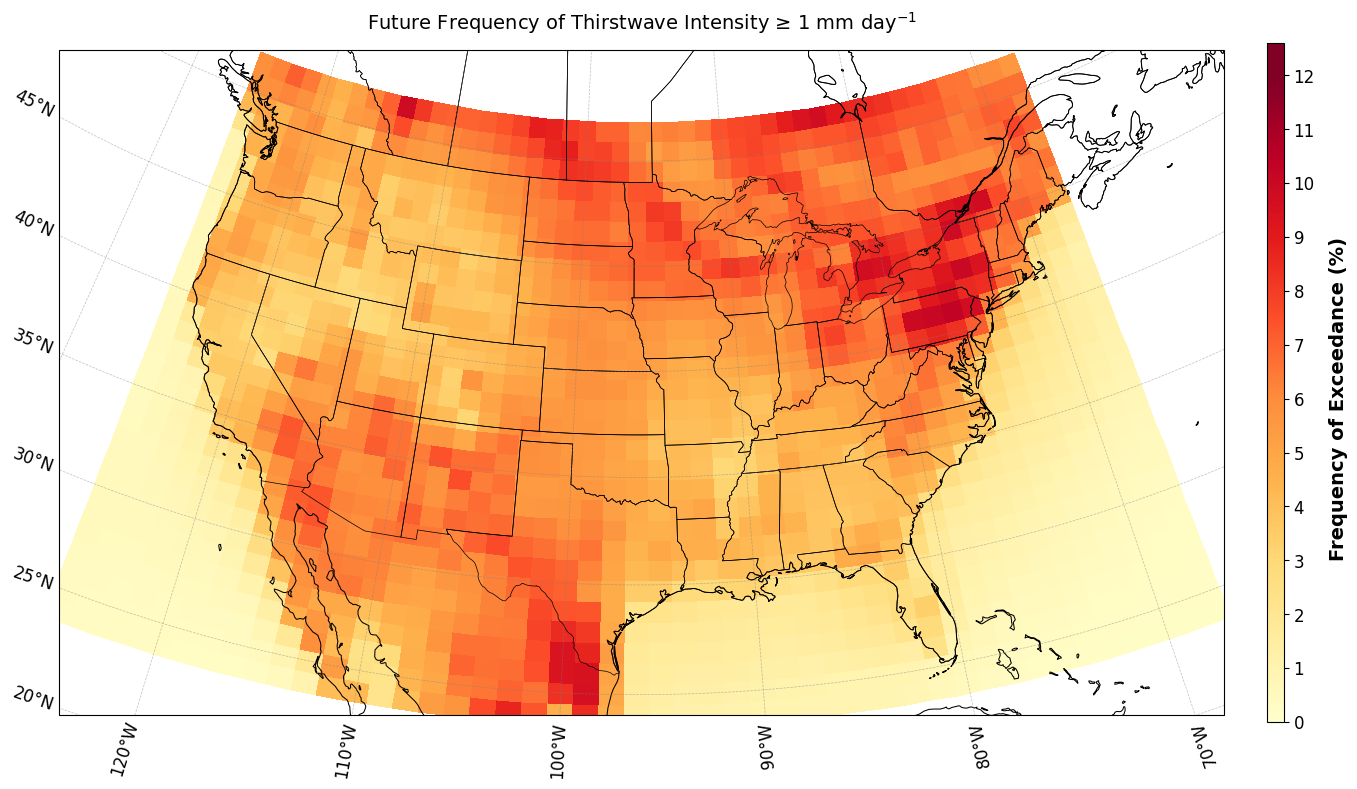

In [8]:
# Pair each DataArray with its specific title to avoid the array-comparison bug
plots_and_titles = [
    (FOE[('hist', 1)], 'Historical Frequency of Thirstwave Intensity ≥ 1 mm day$^{-1}$'),
    (FOE[('ftr', 1)], 'Future Frequency of Thirstwave Intensity ≥ 1 mm day$^{-1}$')
]

for plot, title in plots_and_titles:
    # Define the plot bounds 
    s_lat, n_lat = 24, 52
    w_lon, e_lon = -125, -67

    # Bounding box matching the Lambert Conformal format
    crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

    # Create the plot
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=crs)

    # Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    # Map features
    ax.coastlines('50m', linewidth=0.75)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.5)

    # Calculate ticks dynamically based on the max value
    data_max = float(plot.max())
    max_even = int(np.ceil(data_max / 2) * 2)
    
    # Safeguard step size so you don't end up with hundreds of ticks if max_even is large
    custom_ticks = list(range(0,21,1))

    # Render the background color fill
    im = plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='YlOrRd', 
                   add_colorbar=False, vmin=0.0, vmax=12, robust=True)

    # Drawing gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                      color='gray', alpha=0.5, linestyle='--')

    # Restrict labels to ONLY the bottom and left
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # Style the labels
    gl.xlabel_style = {'size': 12, 'color': 'black'}
    gl.ylabel_style = {'size': 12, 'color': 'black'}

    # Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

    # Vertical colorbar configuration (Now unified for both plots)
    cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                      aspect=40, extend='max', extendrect=True, ticks=custom_ticks) 

    # Colorbar label settings with nice subscripts
    cb.set_label('Frequency of Exceedance (%)', size=14, weight='bold', labelpad=10)
    cb.ax.tick_params(labelsize=12)

    # Dynamic Title
    plt.title(title, fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

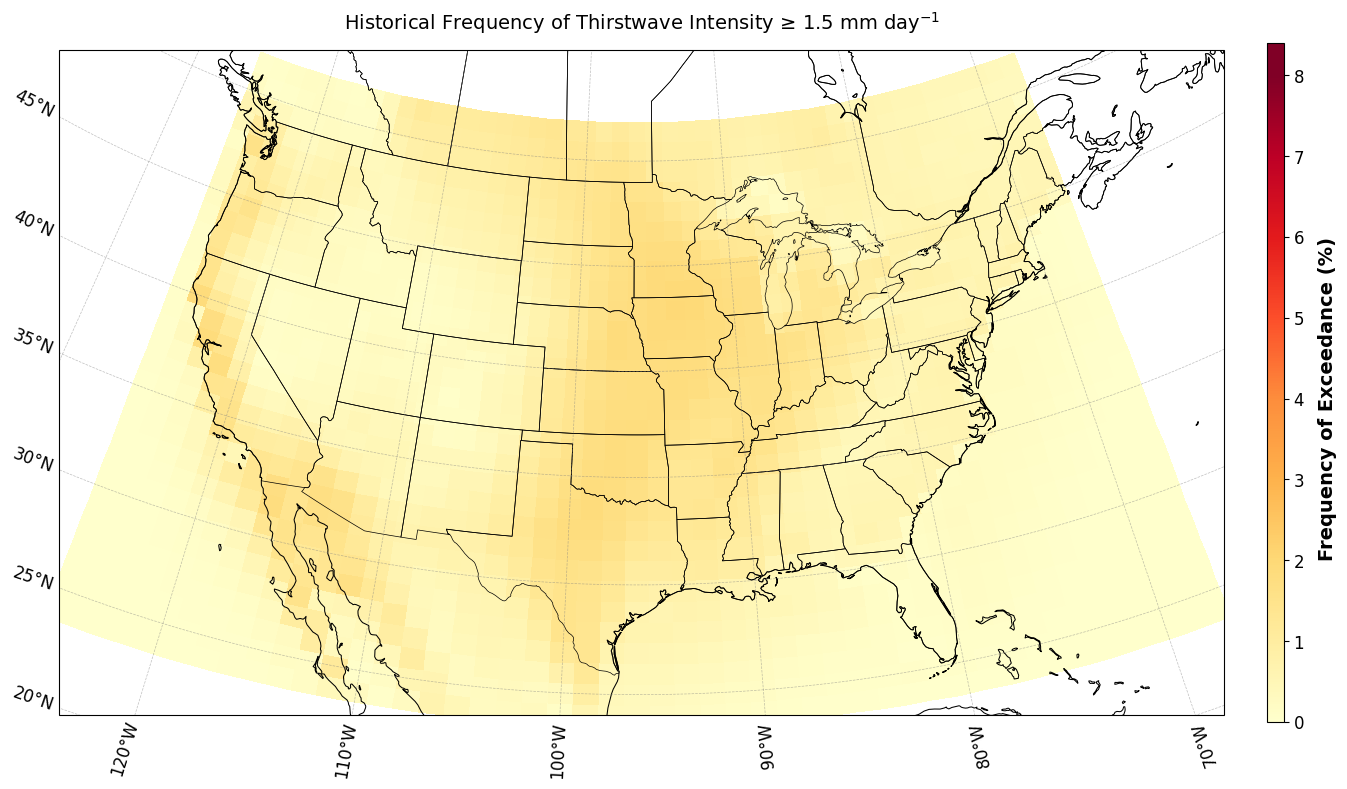

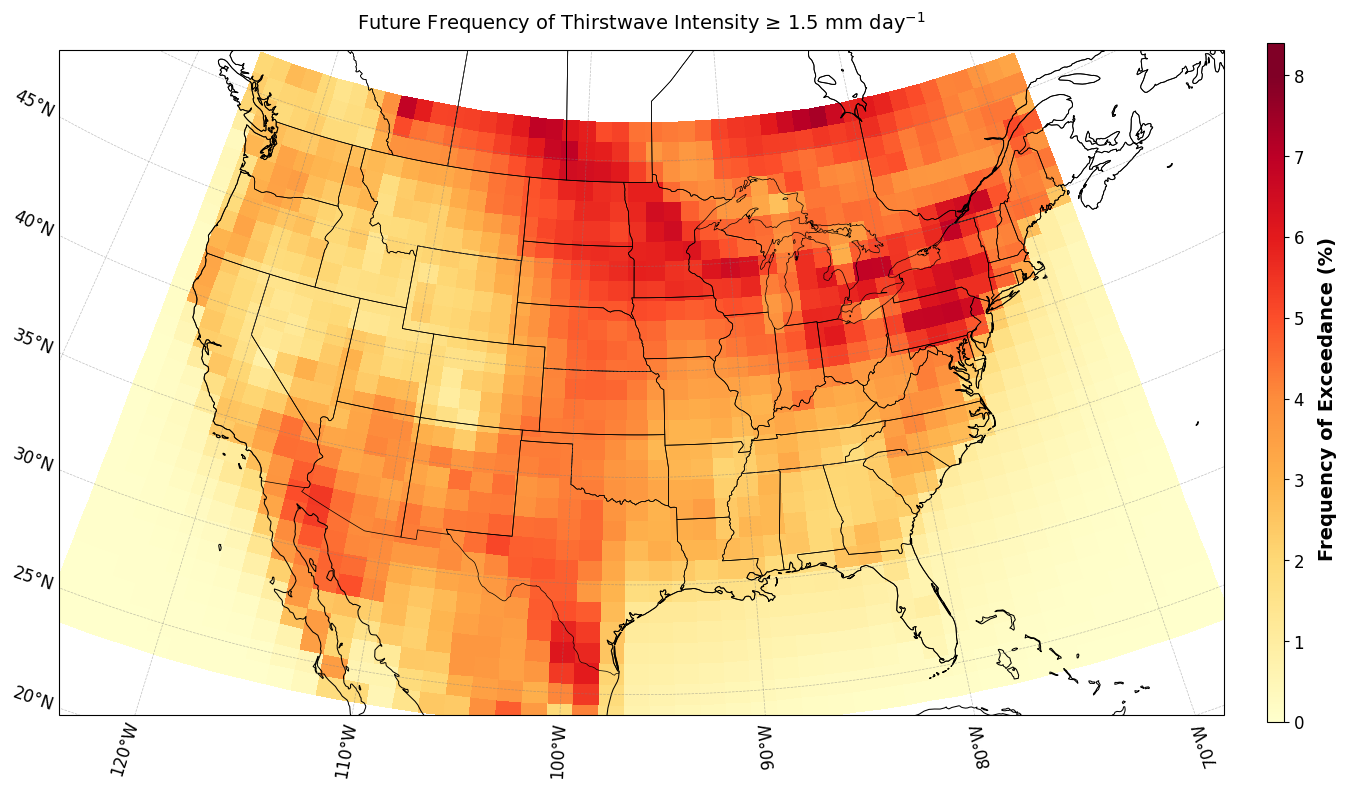

In [9]:
# Pair each DataArray with its specific title to avoid the array-comparison bug
plots_and_titles = [
    (FOE[('hist', 1.5)], 'Historical Frequency of Thirstwave Intensity ≥ 1.5 mm day$^{-1}$'),
    (FOE[('ftr', 1.5)], 'Future Frequency of Thirstwave Intensity ≥ 1.5 mm day$^{-1}$')
]

for plot, title in plots_and_titles:
    # Define the plot bounds 
    s_lat, n_lat = 24, 52
    w_lon, e_lon = -125, -67

    # Bounding box matching the Lambert Conformal format
    crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

    # Create the plot
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=crs)

    # Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    # Map features
    ax.coastlines('50m', linewidth=0.75)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.5)

    # Calculate ticks dynamically based on the max value
    data_max = float(plot.max())
    max_even = int(np.ceil(data_max / 2) * 2)
    
    # Safeguard step size so you don't end up with hundreds of ticks if max_even is large
    custom_ticks = list(range(0,21,1))

    # Render the background color fill
    im = plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='YlOrRd', 
                   add_colorbar=False, vmin=0.0, vmax=8, robust=True)

    # Drawing gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                      color='gray', alpha=0.5, linestyle='--')

    # Restrict labels to ONLY the bottom and left
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # Style the labels
    gl.xlabel_style = {'size': 12, 'color': 'black'}
    gl.ylabel_style = {'size': 12, 'color': 'black'}

    # Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

    # Vertical colorbar configuration (Now unified for both plots)
    cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                      aspect=40, extend='max', extendrect=True, ticks=custom_ticks) 

    # Colorbar label settings with nice subscripts
    cb.set_label('Frequency of Exceedance (%)', size=14, weight='bold', labelpad=10)
    cb.ax.tick_params(labelsize=12)

    # Dynamic Title
    plt.title(title, fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

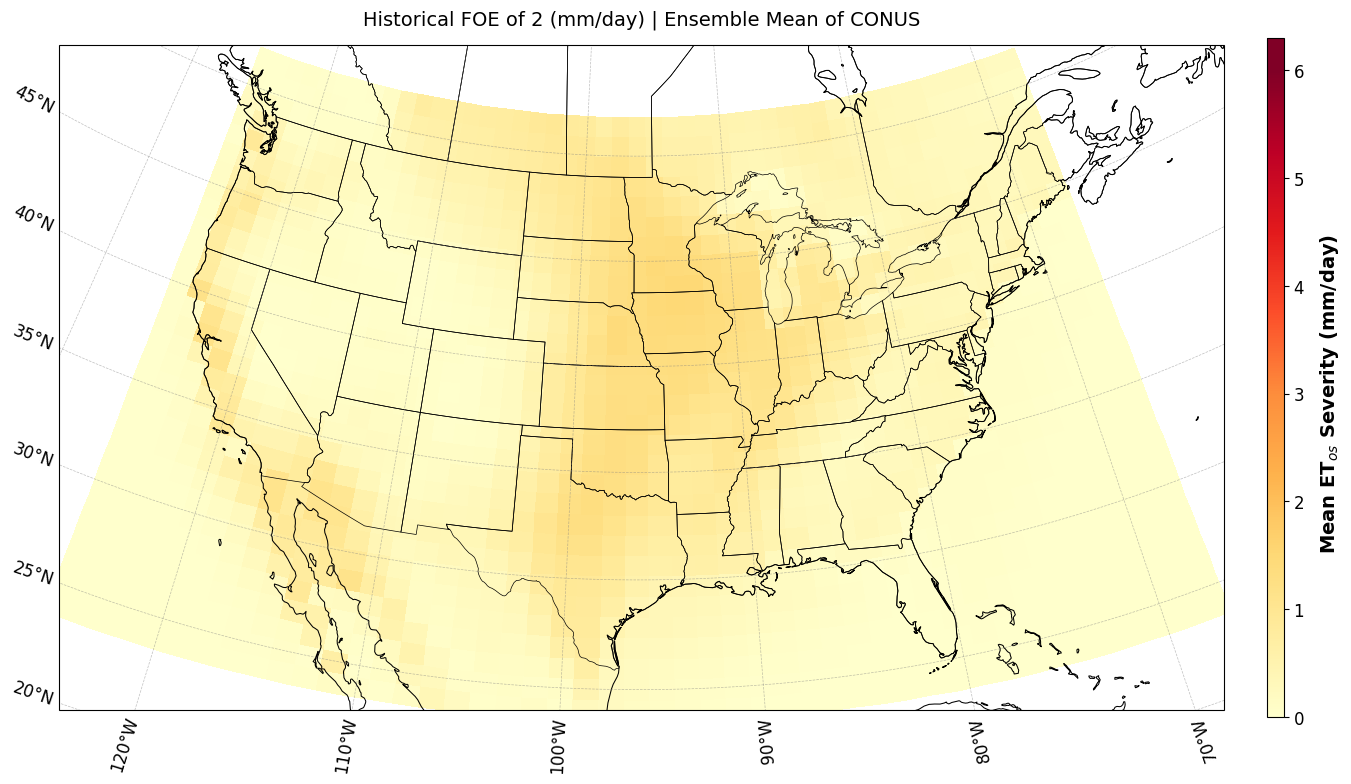

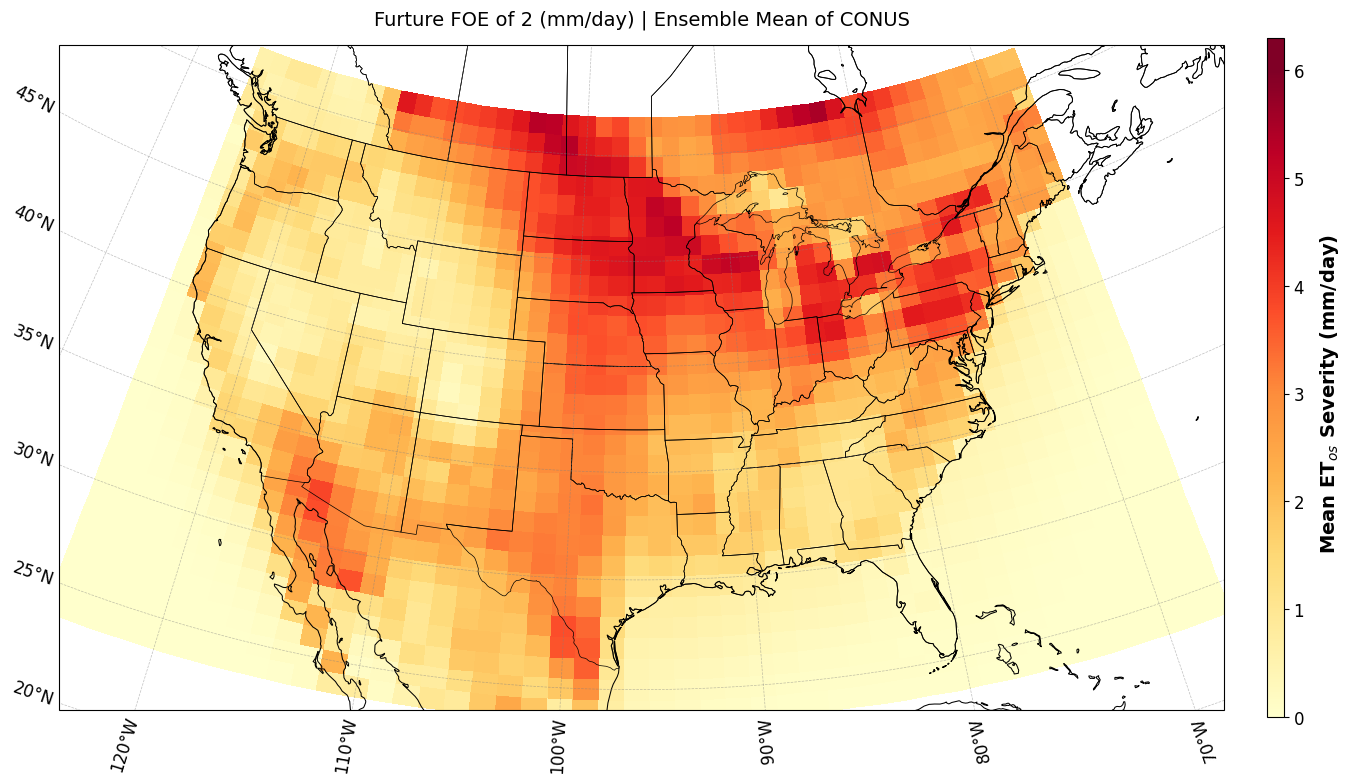

In [10]:
# Pair each DataArray with its specific title to avoid the array-comparison bug
plots_and_titles = [
    (FOE[('hist', 2)], 'Historical FOE of 2 (mm/day) | Ensemble Mean of CONUS'),
    (FOE[('ftr', 2)], 'Furture FOE of 2 (mm/day) | Ensemble Mean of CONUS')
]

for plot, title in plots_and_titles:
    # Define the plot bounds 
    s_lat, n_lat = 24, 52
    w_lon, e_lon = -125, -67

    # Bounding box matching the Lambert Conformal format
    crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

    # Create the plot
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=crs)

    # Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    # Map features
    ax.coastlines('50m', linewidth=0.75)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.5)

    # Calculate ticks dynamically based on the max value
    data_max = float(plot.max())
    max_even = int(np.ceil(data_max / 2) * 2)
    
    # Safeguard step size so you don't end up with hundreds of ticks if max_even is large
    custom_ticks = list(range(0,21,1))

    # Render the background color fill
    im = plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='YlOrRd', 
                   add_colorbar=False, vmin=0.0, vmax=6, robust=True)

    # Drawing gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                      color='gray', alpha=0.5, linestyle='--')

    # Restrict labels to ONLY the bottom and left
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # Style the labels
    gl.xlabel_style = {'size': 12, 'color': 'black'}
    gl.ylabel_style = {'size': 12, 'color': 'black'}

    # Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

    # Vertical colorbar configuration (Now unified for both plots)
    cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                      aspect=40, extend='max', extendrect=True, ticks=custom_ticks) 

    # Colorbar label settings with nice subscripts
    cb.set_label('Mean ET$_{os}$ Severity (mm/day)', size=14, weight='bold', labelpad=10)
    cb.ax.tick_params(labelsize=12)

    # Dynamic Title
    plt.title(title, fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

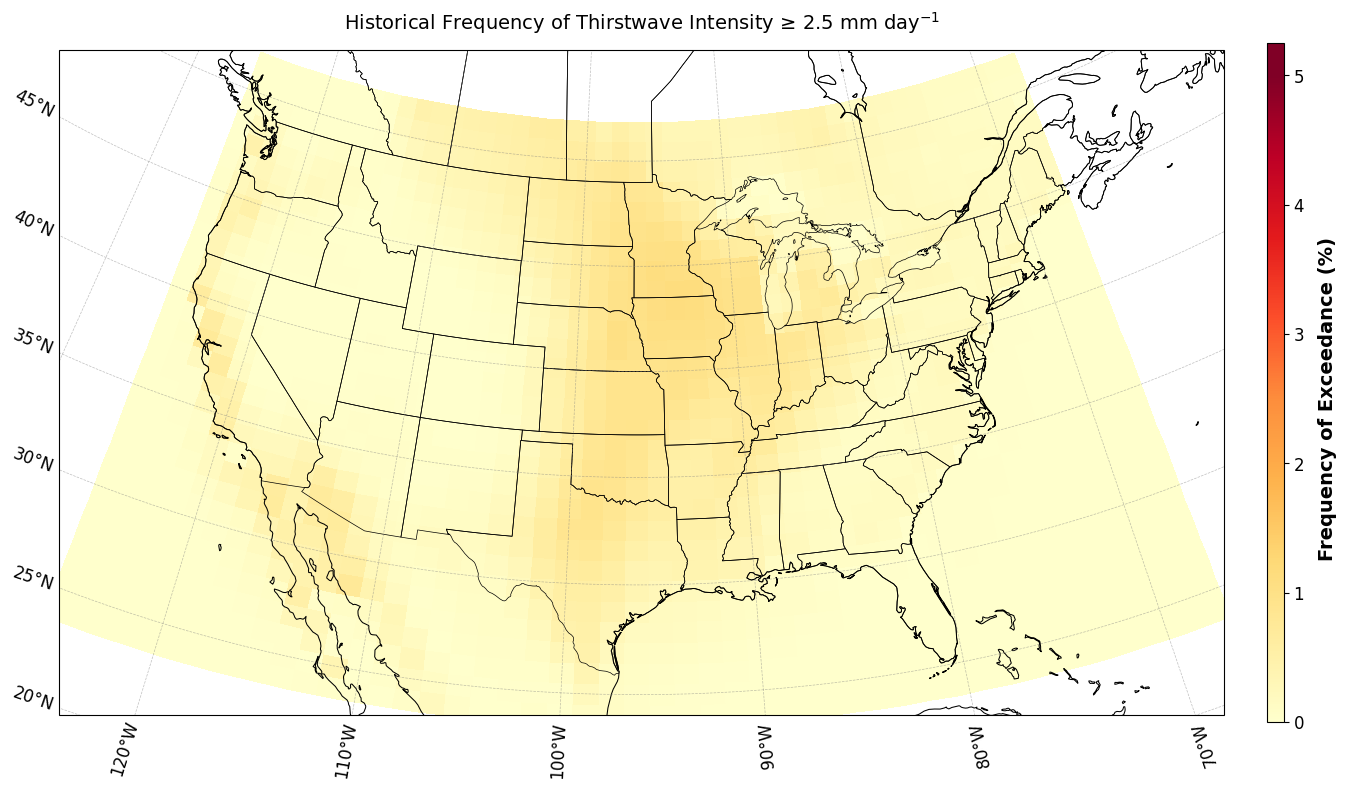

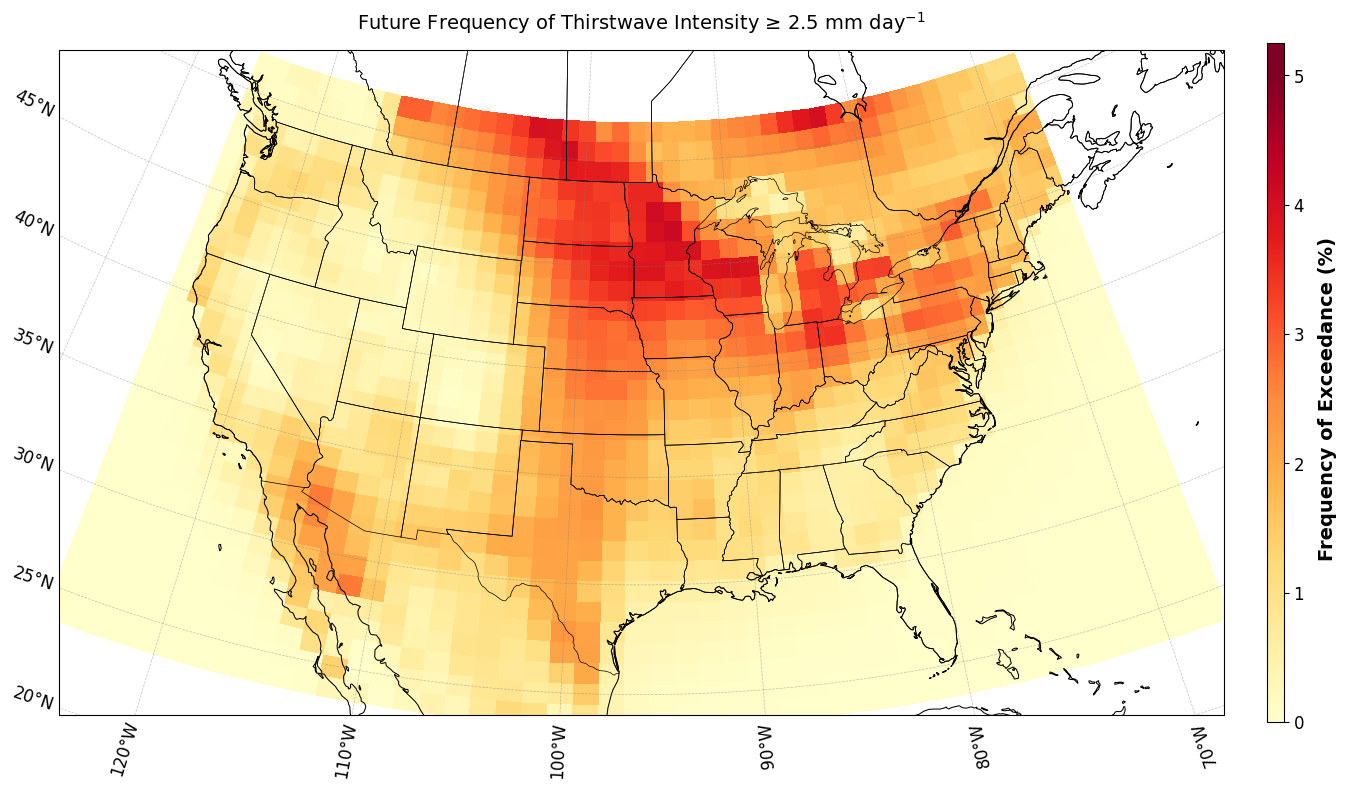

In [11]:
# Pair each DataArray with its specific title to avoid the array-comparison bug
plots_and_titles = [
    (FOE[('hist', 2.5)], 'Historical Frequency of Thirstwave Intensity ≥ 2.5 mm day$^{-1}$'),
    (FOE[('ftr', 2.5)], 'Future Frequency of Thirstwave Intensity ≥ 2.5 mm day$^{-1}$')
]

for plot, title in plots_and_titles:
    # Define the plot bounds 
    s_lat, n_lat = 24, 52
    w_lon, e_lon = -125, -67

    # Bounding box matching the Lambert Conformal format
    crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

    # Create the plot
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=crs)

    # Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    # Map features
    ax.coastlines('50m', linewidth=0.75)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.5)

    # Calculate ticks dynamically based on the max value
    data_max = float(plot.max())
    max_even = int(np.ceil(data_max / 2) * 2)
    
    # Safeguard step size so you don't end up with hundreds of ticks if max_even is large
    custom_ticks = list(range(0,21,1))

    # Render the background color fill
    im = plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='YlOrRd', 
                   add_colorbar=False, vmin=0.0, vmax=5, robust=True)

    # Drawing gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                      color='gray', alpha=0.5, linestyle='--')

    # Restrict labels to ONLY the bottom and left
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # Style the labels
    gl.xlabel_style = {'size': 12, 'color': 'black'}
    gl.ylabel_style = {'size': 12, 'color': 'black'}

    # Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

    # Vertical colorbar configuration (Now unified for both plots)
    cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                      aspect=40, extend='max', extendrect=True, ticks=custom_ticks) 

    # Colorbar label settings with nice subscripts
    cb.set_label('Frequency of Exceedance (%)', size=14, weight='bold', labelpad=10)
    cb.ax.tick_params(labelsize=12)

    # Dynamic Title
    plt.title(title, fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

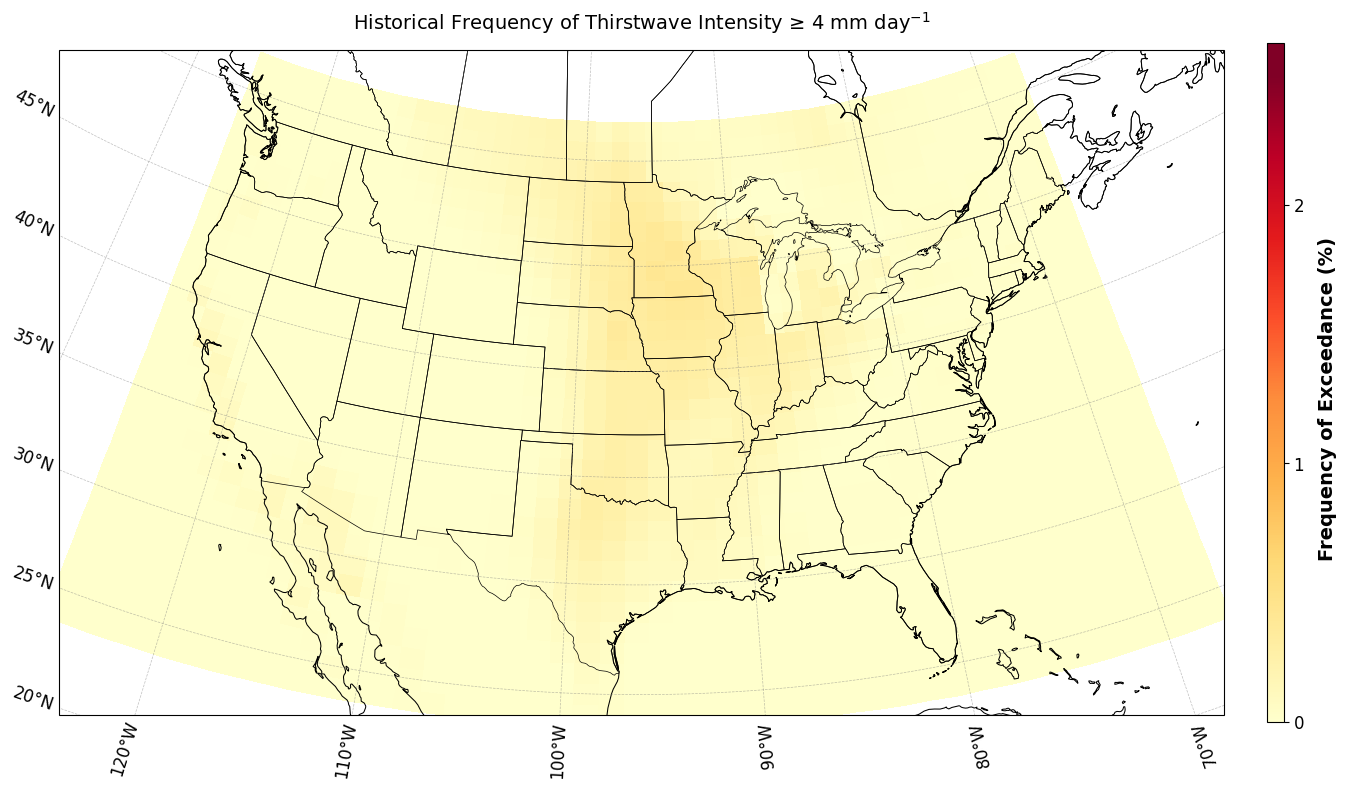

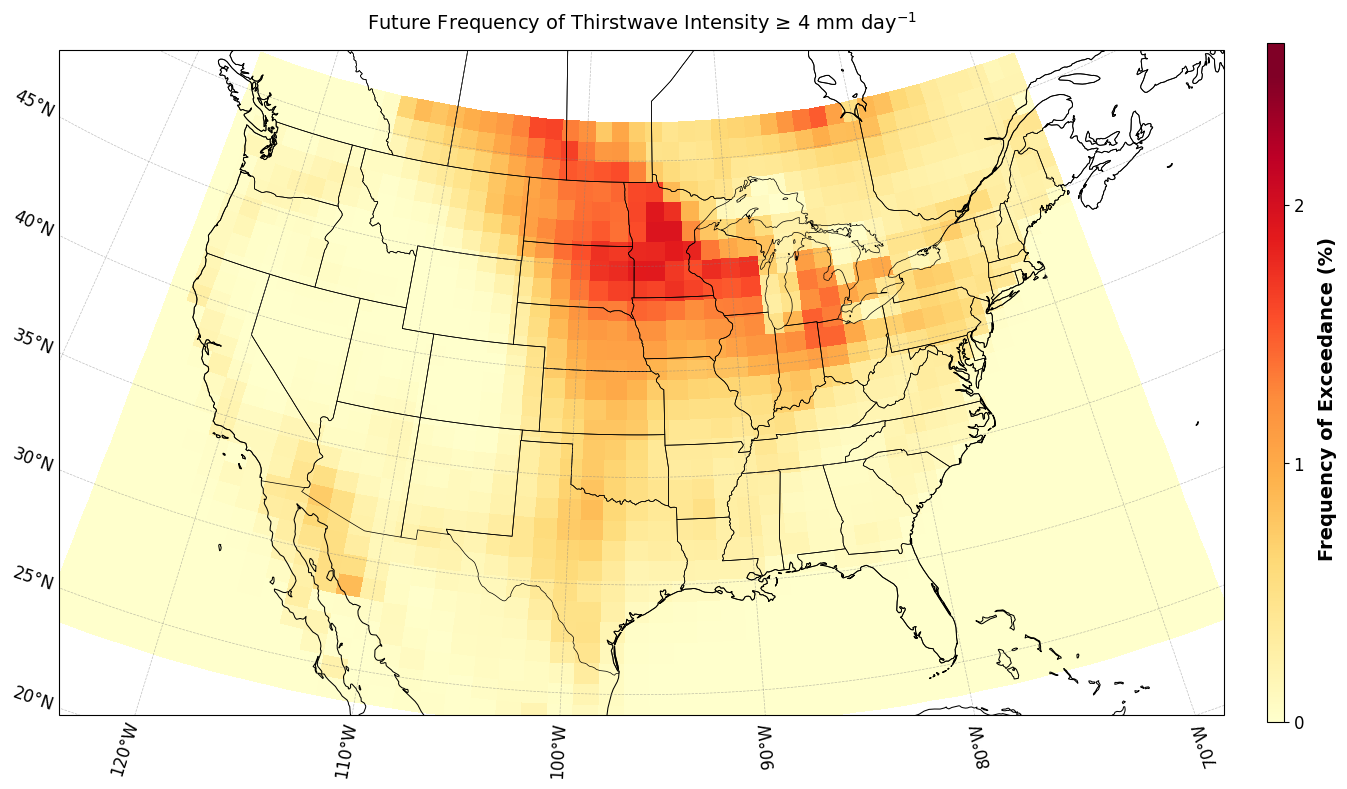

In [12]:
# Pair each DataArray with its specific title to avoid the array-comparison bug
plots_and_titles = [
    (FOE[('hist', 4)], 'Historical Frequency of Thirstwave Intensity ≥ 4 mm day$^{-1}$'),
    (FOE[('ftr', 4)], 'Future Frequency of Thirstwave Intensity ≥ 4 mm day$^{-1}$')
]

for plot, title in plots_and_titles:
    # Define the plot bounds 
    s_lat, n_lat = 24, 52
    w_lon, e_lon = -125, -67

    # Bounding box matching the Lambert Conformal format
    crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

    # Create the plot
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=crs)

    # Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    # Map features
    ax.coastlines('50m', linewidth=0.75)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.5)

    # Calculate ticks dynamically based on the max value
    data_max = float(plot.max())
    max_even = int(np.ceil(data_max / 2) * 2)
    
    # Safeguard step size so you don't end up with hundreds of ticks if max_even is large
    custom_ticks = list(range(0,21,1))

    # Render the background color fill
    im = plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='YlOrRd', 
                   add_colorbar=False, vmin=0.0, vmax=2.5, robust=True)

    # Drawing gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                      color='gray', alpha=0.5, linestyle='--')

    # Restrict labels to ONLY the bottom and left
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # Style the labels
    gl.xlabel_style = {'size': 12, 'color': 'black'}
    gl.ylabel_style = {'size': 12, 'color': 'black'}

    # Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

    # Vertical colorbar configuration (Now unified for both plots)
    cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                      aspect=40, extend='max', extendrect=True, ticks=custom_ticks) 

    # Colorbar label settings with nice subscripts
    cb.set_label('Frequency of Exceedance (%)', size=14, weight='bold', labelpad=10)
    cb.ax.tick_params(labelsize=12)

    # Dynamic Title
    plt.title(title, fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

In [13]:
delta_025 = FOE[('ftr', 0.25)] - FOE[('hist', 0.25)]
delta_05 = FOE[('ftr', 0.5)] - FOE[('hist', 0.5)]
delta_1 = FOE[('ftr', 1)] - FOE[('hist', 1)]
delta_15 = FOE[('ftr', 1.5)] - FOE[('hist', 1.5)]
delta_2 = FOE[('ftr', 2)] - FOE[('hist', 2)]
delta_25 = FOE[('ftr', 2.5)] - FOE[('hist', 2.5)]
delta_4 = FOE[('ftr', 4)] - FOE[('hist', 4)]

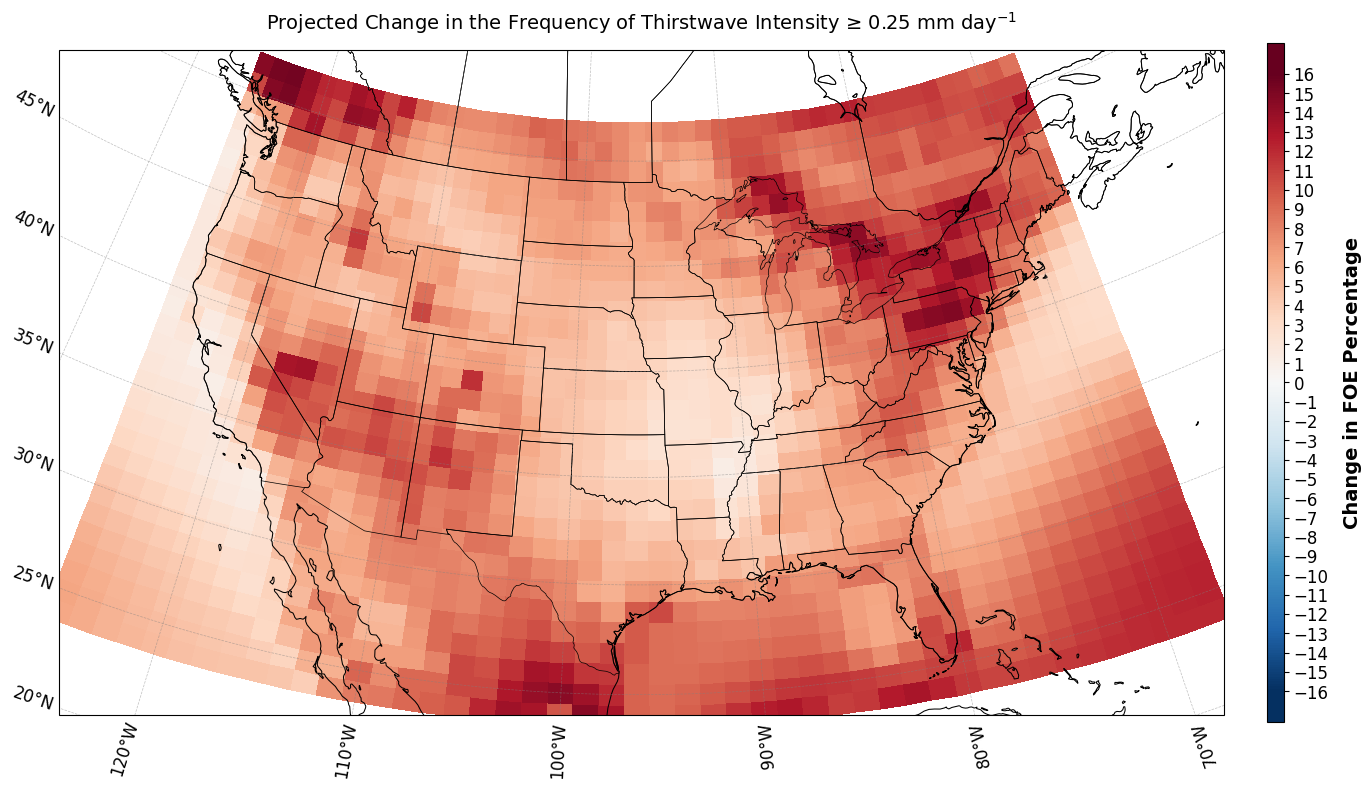

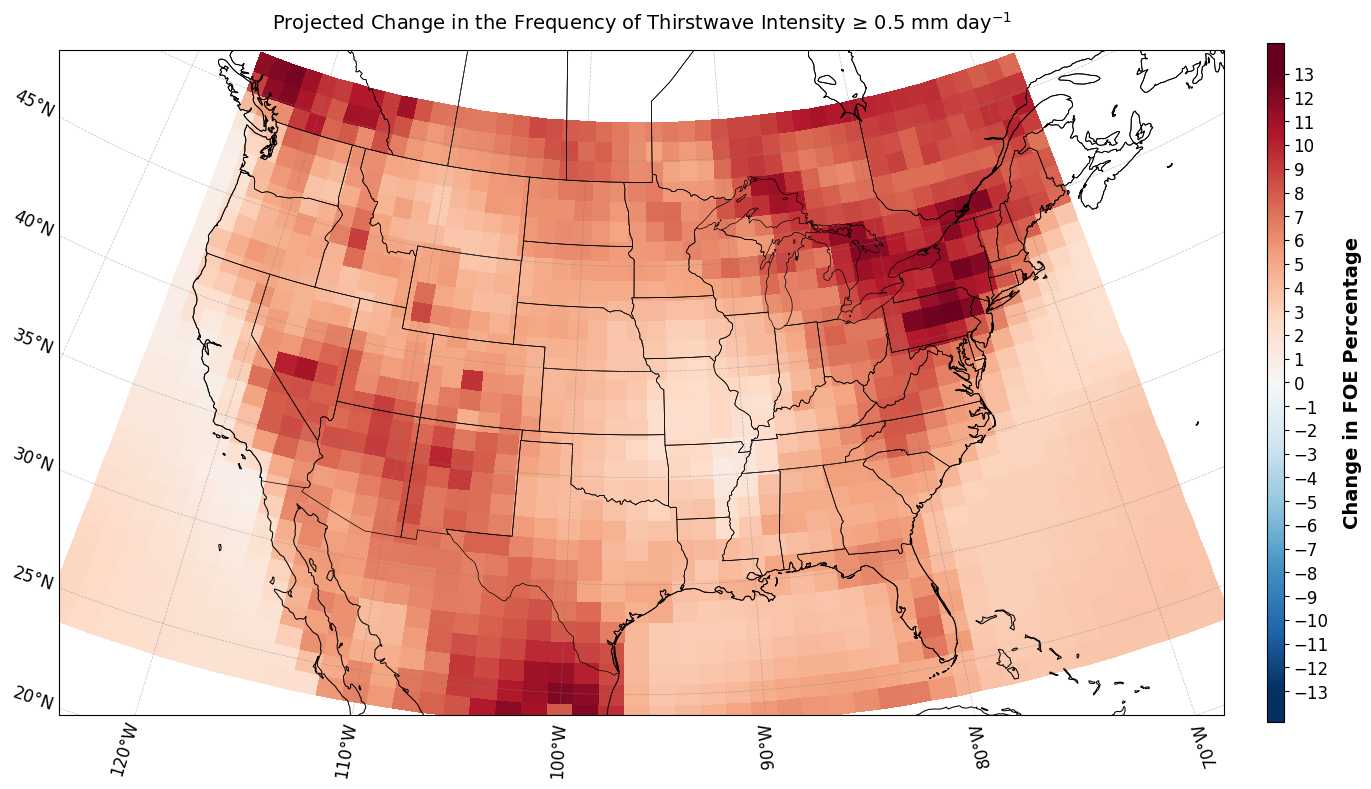

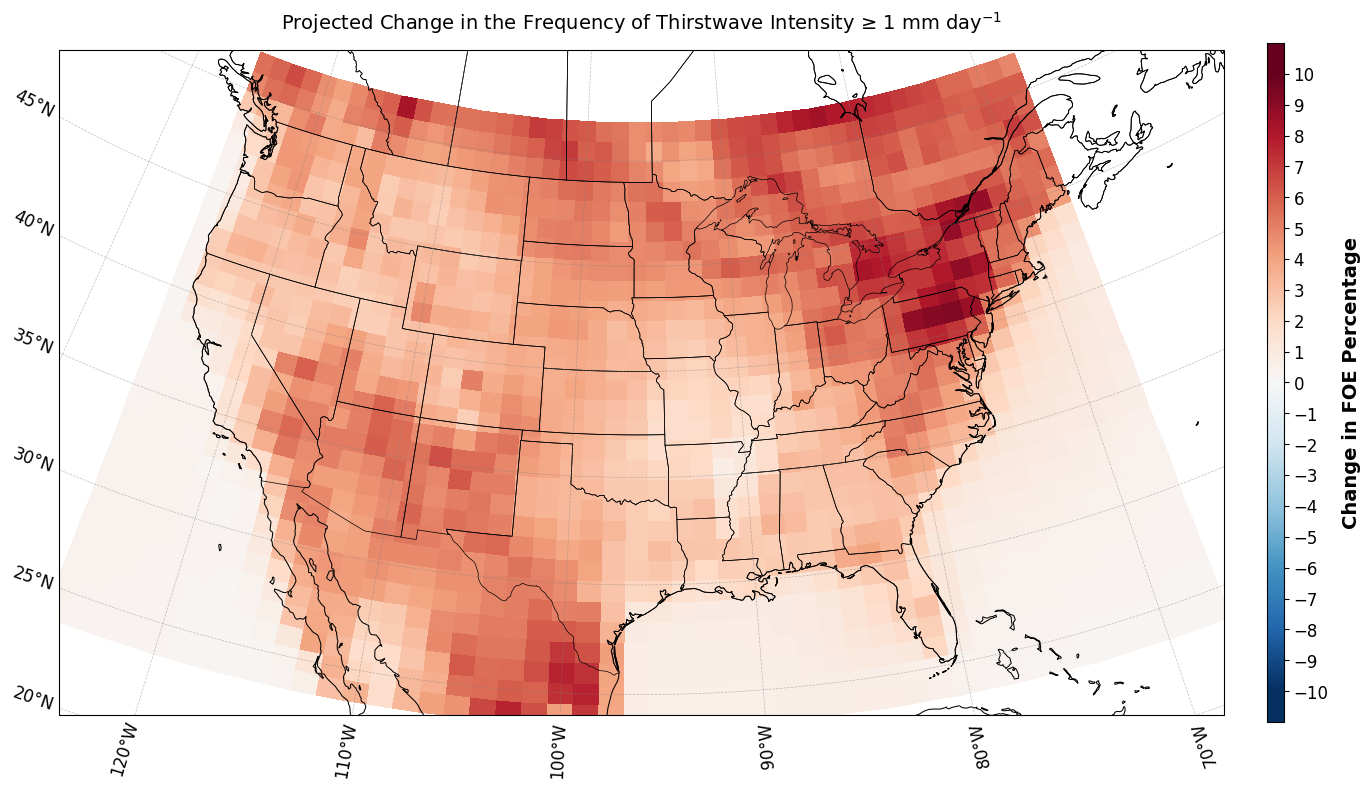

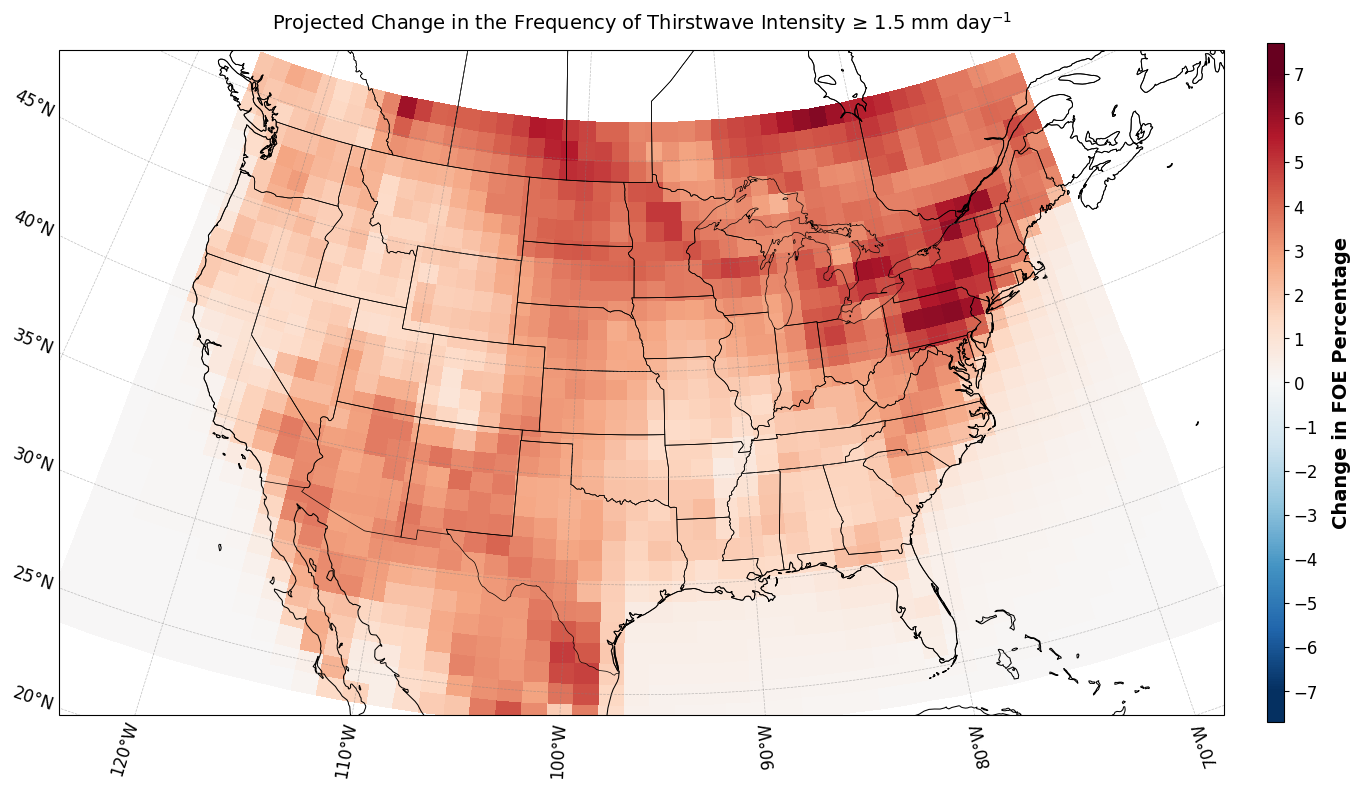

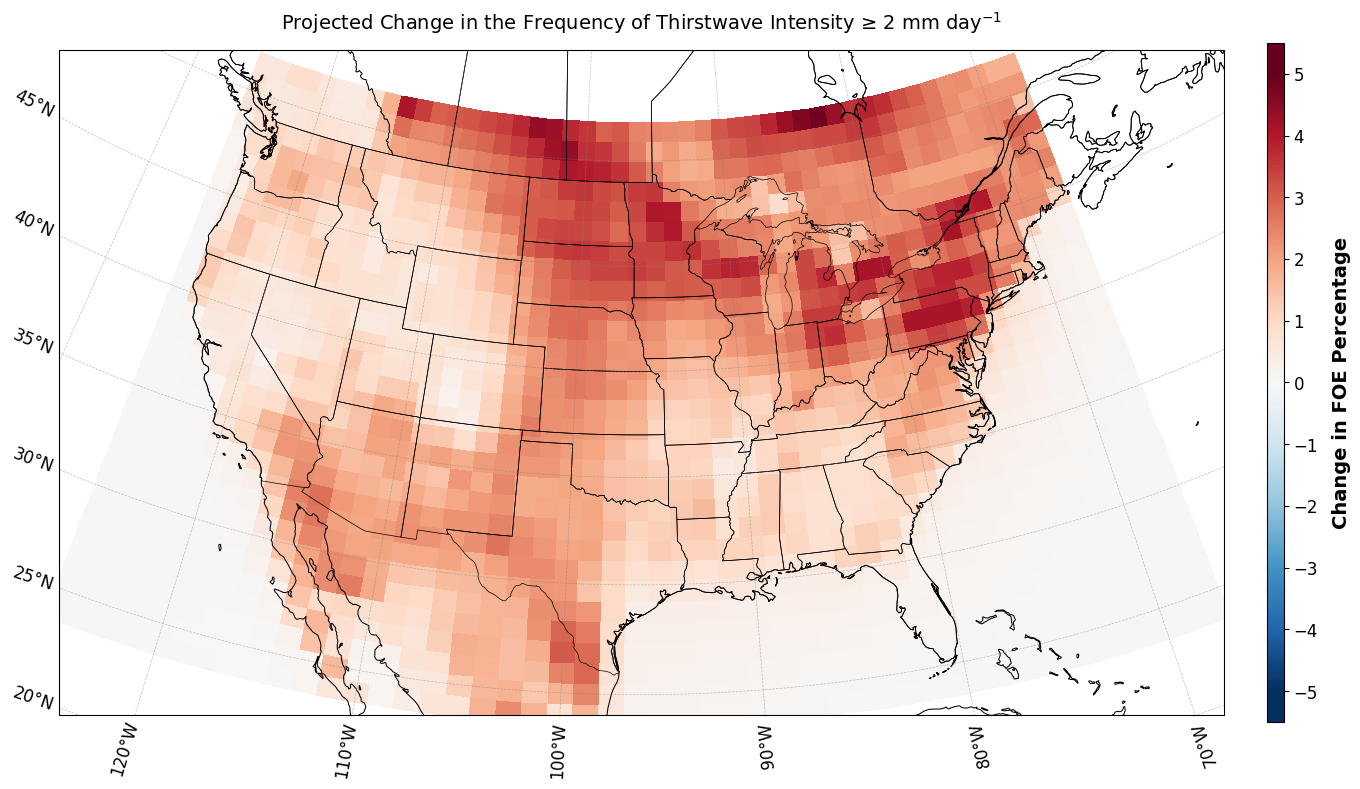

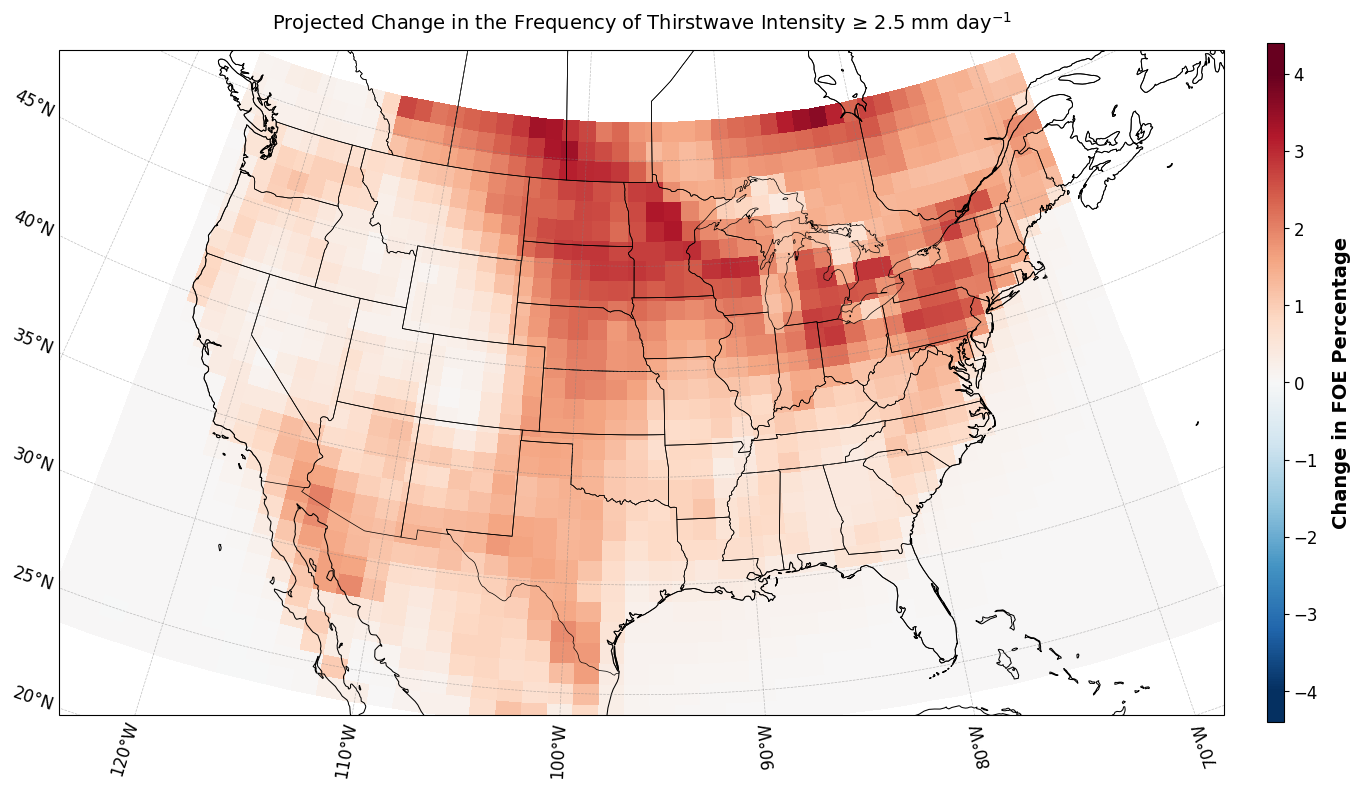

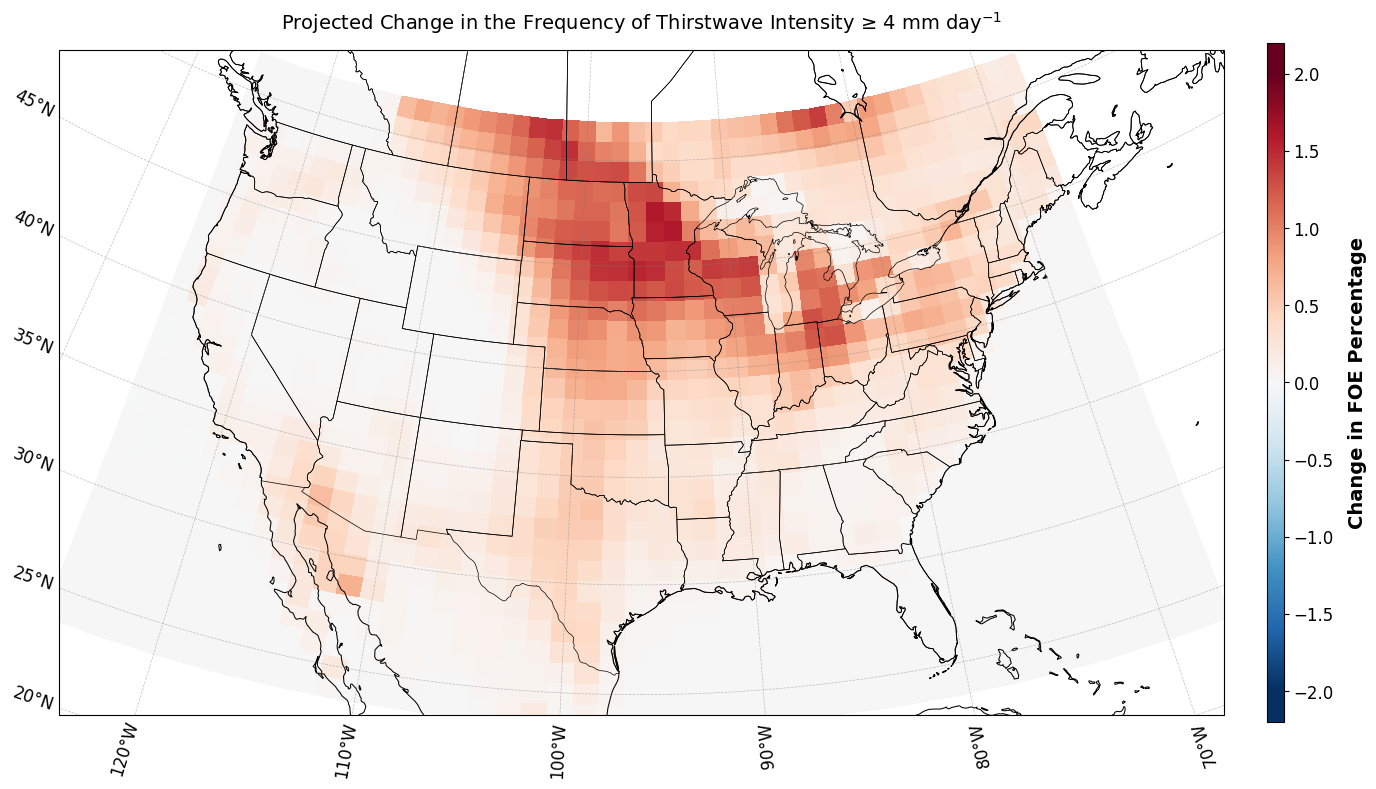

In [14]:
# Pair each delta array with its unique colorbar label and plot title
plots_and_metadata = [
    (delta_025, 'Projected Change in the Frequency of Thirstwave Intensity ≥ 0.25 mm day$^{-1}$', 'Change in FOE Percentage'),
    (delta_05, 'Projected Change in the Frequency of Thirstwave Intensity ≥ 0.5 mm day$^{-1}$', 'Change in FOE Percentage'),
    (delta_1, 'Projected Change in the Frequency of Thirstwave Intensity ≥ 1 mm day$^{-1}$', 'Change in FOE Percentage'),
    (delta_15, 'Projected Change in the Frequency of Thirstwave Intensity ≥ 1.5 mm day$^{-1}$', 'Change in FOE Percentage'),
    (delta_2, 'Projected Change in the Frequency of Thirstwave Intensity ≥ 2 mm day$^{-1}$', 'Change in FOE Percentage'),
    (delta_25, 'Projected Change in the Frequency of Thirstwave Intensity ≥ 2.5 mm day$^{-1}$', 'Change in FOE Percentage'),
    (delta_4, 'Projected Change in the Frequency of Thirstwave Intensity ≥ 4 mm day$^{-1}$', 'Change in FOE Percentage')
]

for plot, title, cb_label in plots_and_metadata:
    # Define the plot bounds 
    s_lat, n_lat = 24, 52
    w_lon, e_lon = -125, -67

    # Bounding box matching the Lambert Conformal format
    crs = ccrs.LambertConformal(central_longitude=-96.2, central_latitude=35, standard_parallels=(30, 60))

    # Create the plot
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=crs)

    # Cartopy always expects -180 to 180 coordinates for set_extent when using PlateCarree
    ax.set_extent([w_lon, e_lon, s_lat, n_lat], crs=ccrs.PlateCarree())  

    # Map features
    ax.coastlines('50m', linewidth=0.75)
    states = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')
    ax.add_feature(states, edgecolor='black', linewidth=0.5)

    # --- DYNAMIC SYMMETRIC RANGE SELECTION ---
    abs_max = max(abs(float(plot.min())), abs(float(plot.max())))

    if abs_max <= 1.0:
        vmax = np.ceil(abs_max * 5) / 5  # Rounds up to nearest 0.2
        tick_step = 0.2
    elif abs_max <= 2.5:
        vmax = np.ceil(abs_max * 2) / 2  # Rounds up to nearest 0.5
        tick_step = 0.5
    else:
        vmax = float(np.ceil(abs_max))   # Rounds up to nearest integer
        tick_step = 1.0

    vmin = -vmax

    # --- CREATE SYMMETRIC TICKS ---
    custom_ticks = np.arange(vmin, vmax + (tick_step * 0.5), tick_step)

    # --- RENDER WITH BALANCED LIMITS ---
    im = plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', 
                   add_colorbar=False, vmin=vmin, vmax=vmax, robust=True)

    # Drawing gridlines using PlateCarree ensures latitude lines are straight and parallel
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, 
                      color='gray', alpha=0.5, linestyle='--')

    # Restrict labels to ONLY the bottom (for longitude) and left (for latitude)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    gl.left_labels = True

    gl.x_inline = False
    gl.y_inline = False

    # Style the labels
    gl.xlabel_style = {'size': 12, 'color': 'black'}
    gl.ylabel_style = {'size': 12, 'color': 'black'}

    # Force clean tick intervals (every 10 degrees for Lon, 5 degrees for Lat)
    gl.xlocator = mticker.FixedLocator(range(-130, -60, 10))
    gl.ylocator = mticker.FixedLocator(range(20, 55, 5))

    # Unified Vertical colorbar configuration 
    cb = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.03, shrink=0.7, 
                      aspect=40, extend='both', extendrect=True, ticks=custom_ticks) 

    # Dynamic colorbar label settings with nice subscripts
    cb.set_label(cb_label, size=14, weight='bold', labelpad=10)
    cb.ax.tick_params(labelsize=12)

    # Dynamic Title 
    plt.title(title, fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()